# Perbandingan Model Regresi — Efikasi Diri & Tingkat Stres

Notebook ini membandingkan **3 varian model regresi linear** untuk menganalisis hubungan antara efikasi diri (X) dan tingkat stres mahasiswa (Y):

| Model | Formula | Keterangan |
|-------|---------|------------|
| **Model 1** | Y = f(X1…X10, Kelas, Gender) | 10 item individu sebagai prediktor |
| **Model 2** | Y = f(X_mean, Kelas, Gender) | X diagregasi menjadi 1 skor rata-rata |
| **Model 3** | Y_faktor = f(X_mean, Kelas, Gender) | 5 model terpisah per faktor Y |

## 1. Setup & Konfigurasi

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import random
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# --- Seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Konstanta ---
OHE_COLS   = ['Gender', 'Kelas']
X_ITEM_COLS = [f'X{i}' for i in range(1, 11)]

FAKTOR_MAP = {
    'Y - Faktor 2': ['Y1',  'Y2',  'Y3',  'Y4',  'Y5' ],
    'Y - Faktor 3': ['Y6',  'Y7',  'Y8',  'Y9'        ],
    'Y - Faktor 5': ['Y10', 'Y11', 'Y12', 'Y13'       ],
    'Y - Faktor 6': ['Y14', 'Y15', 'Y16'              ],
    'Y - Faktor 7': ['Y17', 'Y18', 'Y19', 'Y20'       ],
}

print('✅ Setup selesai.')

✅ Setup selesai.


## 2. Load Data

In [156]:
var_y = pd.read_csv('var_y.csv')
df    = pd.read_csv('df.csv')
var_x = df[X_ITEM_COLS]


print(f'var_y : {var_y.shape}  →  {list(var_y.columns)}')
print(f'df    : {df.shape}    →  {list(df.columns)}')

var_y : (69, 20)  →  ['Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6', 'Y7', 'Y8', 'Y9', 'Y10', 'Y11', 'Y12', 'Y13', 'Y14', 'Y15', 'Y16', 'Y17', 'Y18', 'Y19', 'Y20']
df    : (69, 12)    →  ['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']


In [157]:
display(var_y.head(3))
display(df.head(3))

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
0,2,5,5,5,4,5,5,5,5,3,3,2,5,4,4,2,5,4,3,5
1,2,2,4,3,4,2,4,4,4,3,4,4,4,2,2,2,5,4,5,5
2,3,2,5,4,2,3,4,5,3,3,4,4,4,3,3,2,3,3,3,2


,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2


## 3. Analisis Populasi & Sampel

**Populasi Total B28 Data Science Kemanggisan (G. Anggrek): 127–167 mahasiswa**

| Kelas | Populasi |
|-------|----------|
| LA09  | 34       |
| LB09  | 35       |
| LC09  | 32       |
| LD09  | 32       |
| LE09  | 34       |

In [158]:
print('=== Distribusi Kelas ===')
print(df['Gender'].value_counts().sort_index().to_frame())

=== Distribusi Kelas ===
        count
Gender       
Pria       49
Wanita     20


In [159]:
print('=== Distribusi Sampel ===')
print(df[['Kelas', 'Gender']].value_counts().sort_index().to_frame())

=== Distribusi Sampel ===
              count
Kelas Gender       
LA09  Pria       11
      Wanita      6
LB09  Pria       15
      Wanita      9
LC09  Pria       12
      Wanita      3
LD09  Pria        4
      Wanita      1
LE09  Pria        7
      Wanita      1


## 4. Eksplorasi Data (EDA)

### Data Demografi Responden

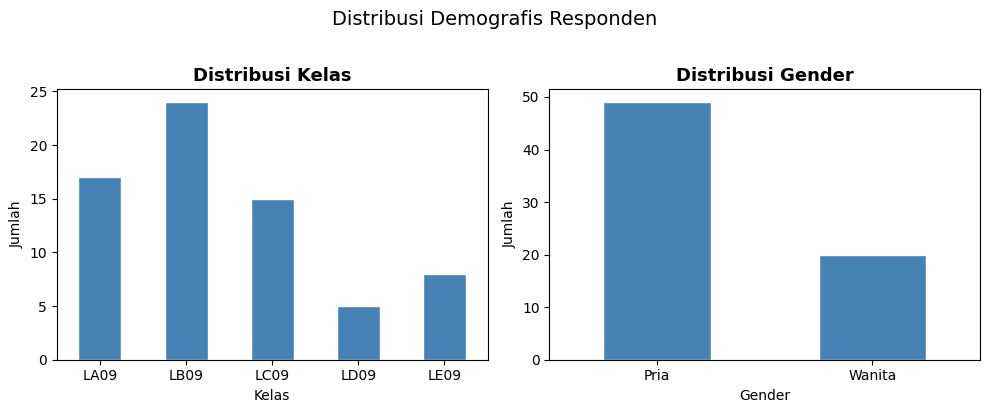

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ['Kelas', 'Gender']):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribusi {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Demografis Responden', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Analisis Variabel X

In [161]:
var_x.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
count,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000
mean,3.362319,3.043478,2.710145,2.695652,2.739130,3.289855,2.855072,2.942029,2.927536,2.898551
std,0.568047,0.736342,0.709214,0.713408,0.678497,0.620755,0.670280,0.683504,0.671233,0.597665
min,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000
25%,3.000000,3.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,4.000000,4.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


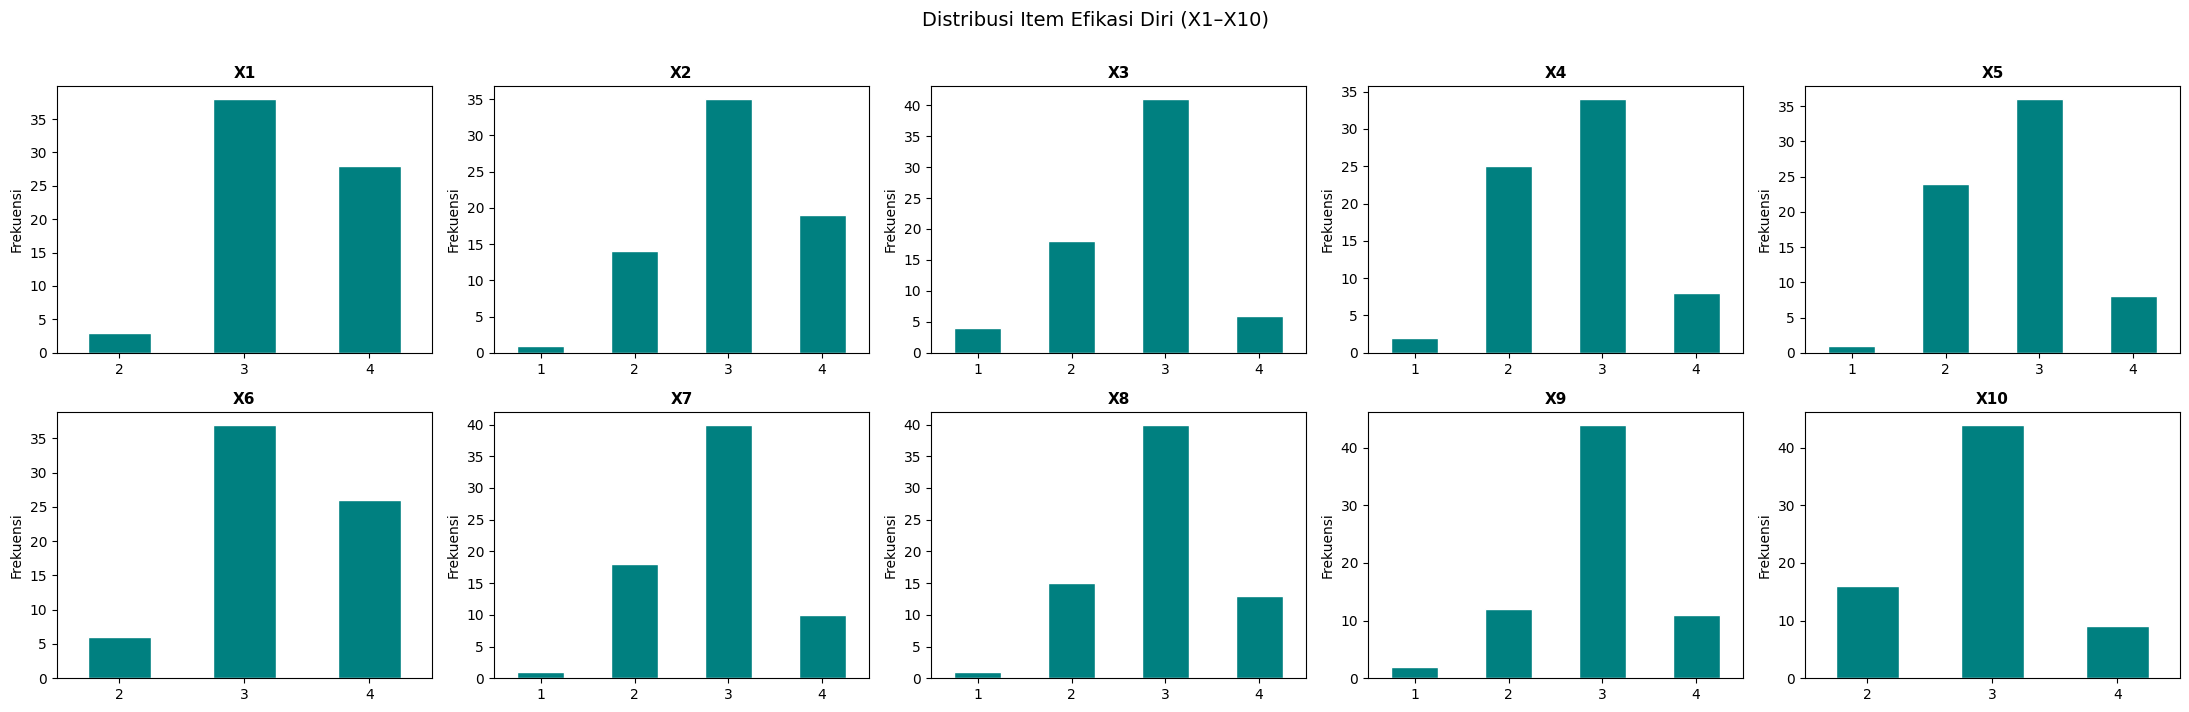

In [162]:
# Distribusi item X (efikasi diri)
fig, axes = plt.subplots(2, 5, figsize=(22, 7))
axes = axes.flatten()

for i, col in enumerate(var_x.columns):
    var_x[col].value_counts().sort_index().plot(kind='bar', ax=axes[i],
                                                color='teal', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Item Efikasi Diri (X1–X10)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [163]:
item_cols = [f"X{i}" for i in range(1, 11)]
missing = [c for c in item_cols if c not in var_x.columns]
if missing:
    print(f"Kolom tidak ditemukan: {missing}")
else:
    df_x = var_x.copy()

    # Agregasi — sum dan mean per responden (per baris)
    df_x["skor_total"] = df_x[item_cols].sum(axis=1)
    df_x["skor_mean"]  = df_x[item_cols].mean(axis=1).round(2)

    print(f"Jumlah responden : {len(df_x)}")
    print(f"Range skor total : {df_x['skor_total'].min()} – {df_x['skor_total'].max()}")
    print(f"Range skor mean  : {df_x['skor_mean'].min():.2f} – {df_x['skor_mean'].max():.2f}")
    print(df_x[["skor_total", "skor_mean"]].head())

Jumlah responden : 69
Range skor total : 18 – 40
Range skor mean  : 1.80 – 4.00
   skor_total  skor_mean
0          25        2.5
1          22        2.2
2          29        2.9
3          32        3.2
4          28        2.8


In [164]:
# Interval berdasarkan skor mean (skala 1–4)
def kategorisasi_x(mean):
    if mean <= 1.75:
        return "Sangat Rendah"
    elif mean <= 2.5:
        return "Rendah"
    elif mean <= 3.25:
        return "Tinggi"
    else:
        return "Sangat Tinggi"

df_x["kategori"] = df_x["skor_mean"].apply(kategorisasi_x)

# Ringkasan distribusi kategori
dist = df_x["kategori"].value_counts().reindex(
    ["Sangat Rendah", "Rendah", "Tinggi", "Sangat Tinggi"]
).fillna(0).astype(int)

dist_pct = (dist / len(df_x) * 100).round(1)

print(pd.DataFrame({"Frekuensi": dist, "Persentase (%)": dist_pct}))

               Frekuensi  Persentase (%)
kategori                                
Sangat Rendah          0             0.0
Rendah                14            20.3
Tinggi                40            58.0
Sangat Tinggi         15            21.7


In [165]:
print("=== SKOR TOTAL (range 10–40) ===")
print(df_x["skor_total"].describe().round(2))

print("\n=== SKOR MEAN (range 1–4) ===")
print(df_x["skor_mean"].describe().round(2))

=== SKOR TOTAL (range 10–40) ===
count    69.00
mean     29.46
std       4.66
min      18.00
25%      26.00
50%      29.00
75%      32.00
max      40.00
Name: skor_total, dtype: float64

=== SKOR MEAN (range 1–4) ===
count    69.00
mean      2.95
std       0.47
min       1.80
25%       2.60
50%       2.90
75%       3.20
max       4.00
Name: skor_mean, dtype: float64


In [166]:
# Interpretasi otomatis dari grand mean
grand_mean_x = df_x["skor_mean"].mean()
kategori_umum_x = kategorisasi_x(grand_mean_x)

print(f"\nGrand mean  : {grand_mean_x:.2f}")
print(f"Interpretasi: Secara keseluruhan, Efikasi Diri mahasiswa B28 Kemanggisan")
print(f"              berada di kategori '{kategori_umum_x}'")


Grand mean  : 2.95
Interpretasi: Secara keseluruhan, Efikasi Diri mahasiswa B28 Kemanggisan
              berada di kategori 'Tinggi'


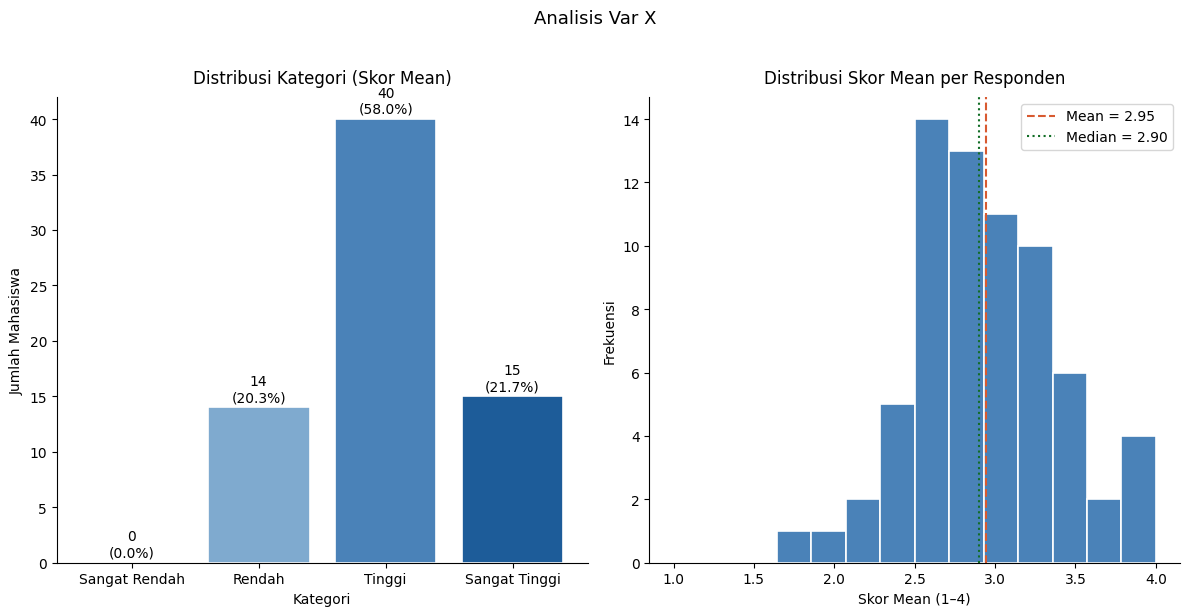

In [167]:
median_val = df_x["skor_mean"].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Chart kiri — distribusi kategori (bar)
kategori_order = ["Sangat Rendah", "Rendah", "Tinggi", "Sangat Tinggi"]
colors = ["#c4d4e8", "#7faacf", "#4a82b8", "#1d5c99"]

axes[0].bar(kategori_order,
            [dist.get(k, 0) for k in kategori_order],
            color=colors, edgecolor="white", linewidth=1.2)

for i, k in enumerate(kategori_order):
    val = dist.get(k, 0)
    pct = val / len(df_x) * 100
    axes[0].text(i, val + 0.3, f"{val}\n({pct:.1f}%)",
                 ha="center", va="bottom", fontsize=10)

axes[0].set_title("Distribusi Kategori (Skor Mean)", fontsize=12, pad=10)
axes[0].set_ylabel("Jumlah Mahasiswa")
axes[0].set_xlabel("Kategori")
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0].spines[["top", "right"]].set_visible(False)

# Chart kanan — histogram skor mean
axes[1].hist(df_x["skor_mean"], bins=14, range=(1, 4),
             color="#4a82b8", edgecolor="white", linewidth=1.2)
axes[1].axvline(grand_mean_x, color="#d85a30", linewidth=1.5,
                linestyle="--", label=f"Mean = {grand_mean_x:.2f}")
axes[1].axvline(median_val, color="#116d25", linewidth=1.5,
                linestyle=":", label=f"Median = {median_val:.2f}")
axes[1].set_title("Distribusi Skor Mean per Responden", fontsize=12, pad=10)
axes[1].set_ylabel("Frekuensi")
axes[1].set_xlabel("Skor Mean (1–4)")
axes[1].legend(fontsize=10)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Analisis Var X",
             fontsize=13, fontweight="500", y=1.02)
plt.tight_layout()
plt.show()

In [168]:
item_means = df_x[item_cols].mean().round(2)

print("=== MEAN PER ITEM (diurutkan terendah ke tertinggi) ===")
for item, val in item_means.items():
    bar = "█" * int(val * 5)
    print(f"  {item:4s} : {val:.2f}  {bar}")

=== MEAN PER ITEM (diurutkan terendah ke tertinggi) ===
  X1   : 3.36  ████████████████
  X2   : 3.04  ███████████████
  X3   : 2.71  █████████████
  X4   : 2.70  █████████████
  X5   : 2.74  █████████████
  X6   : 3.29  ████████████████
  X7   : 2.86  ██████████████
  X8   : 2.94  ██████████████
  X9   : 2.93  ██████████████
  X10  : 2.90  ██████████████


### Analisis Variabel Y

In [169]:
var_y[[f"Y{i}" for i in range(1, 11)]].describe()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10
count,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000
mean,2.347826,2.217391,3.565217,3.478261,3.536232,3.202899,4.000000,3.565217,3.289855,2.681159
std,0.920775,1.012707,1.169191,1.195687,1.092484,1.219688,1.084652,1.218464,1.044614,1.131017
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000
50%,2.000000,2.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,3.000000
75%,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,3.000000
max,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [170]:
var_y[[f"Y{i}" for i in range(11, 21)]].describe()

,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20
count,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000
mean,2.695652,2.463768,3.376812,2.811594,2.681159,2.260870,3.101449,3.144928,3.550725,3.347826
std,1.167002,1.008489,1.225962,1.018583,1.077753,0.979979,1.100066,1.088379,0.993156,1.186023
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000
50%,2.000000,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,3.000000,4.000000
75%,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


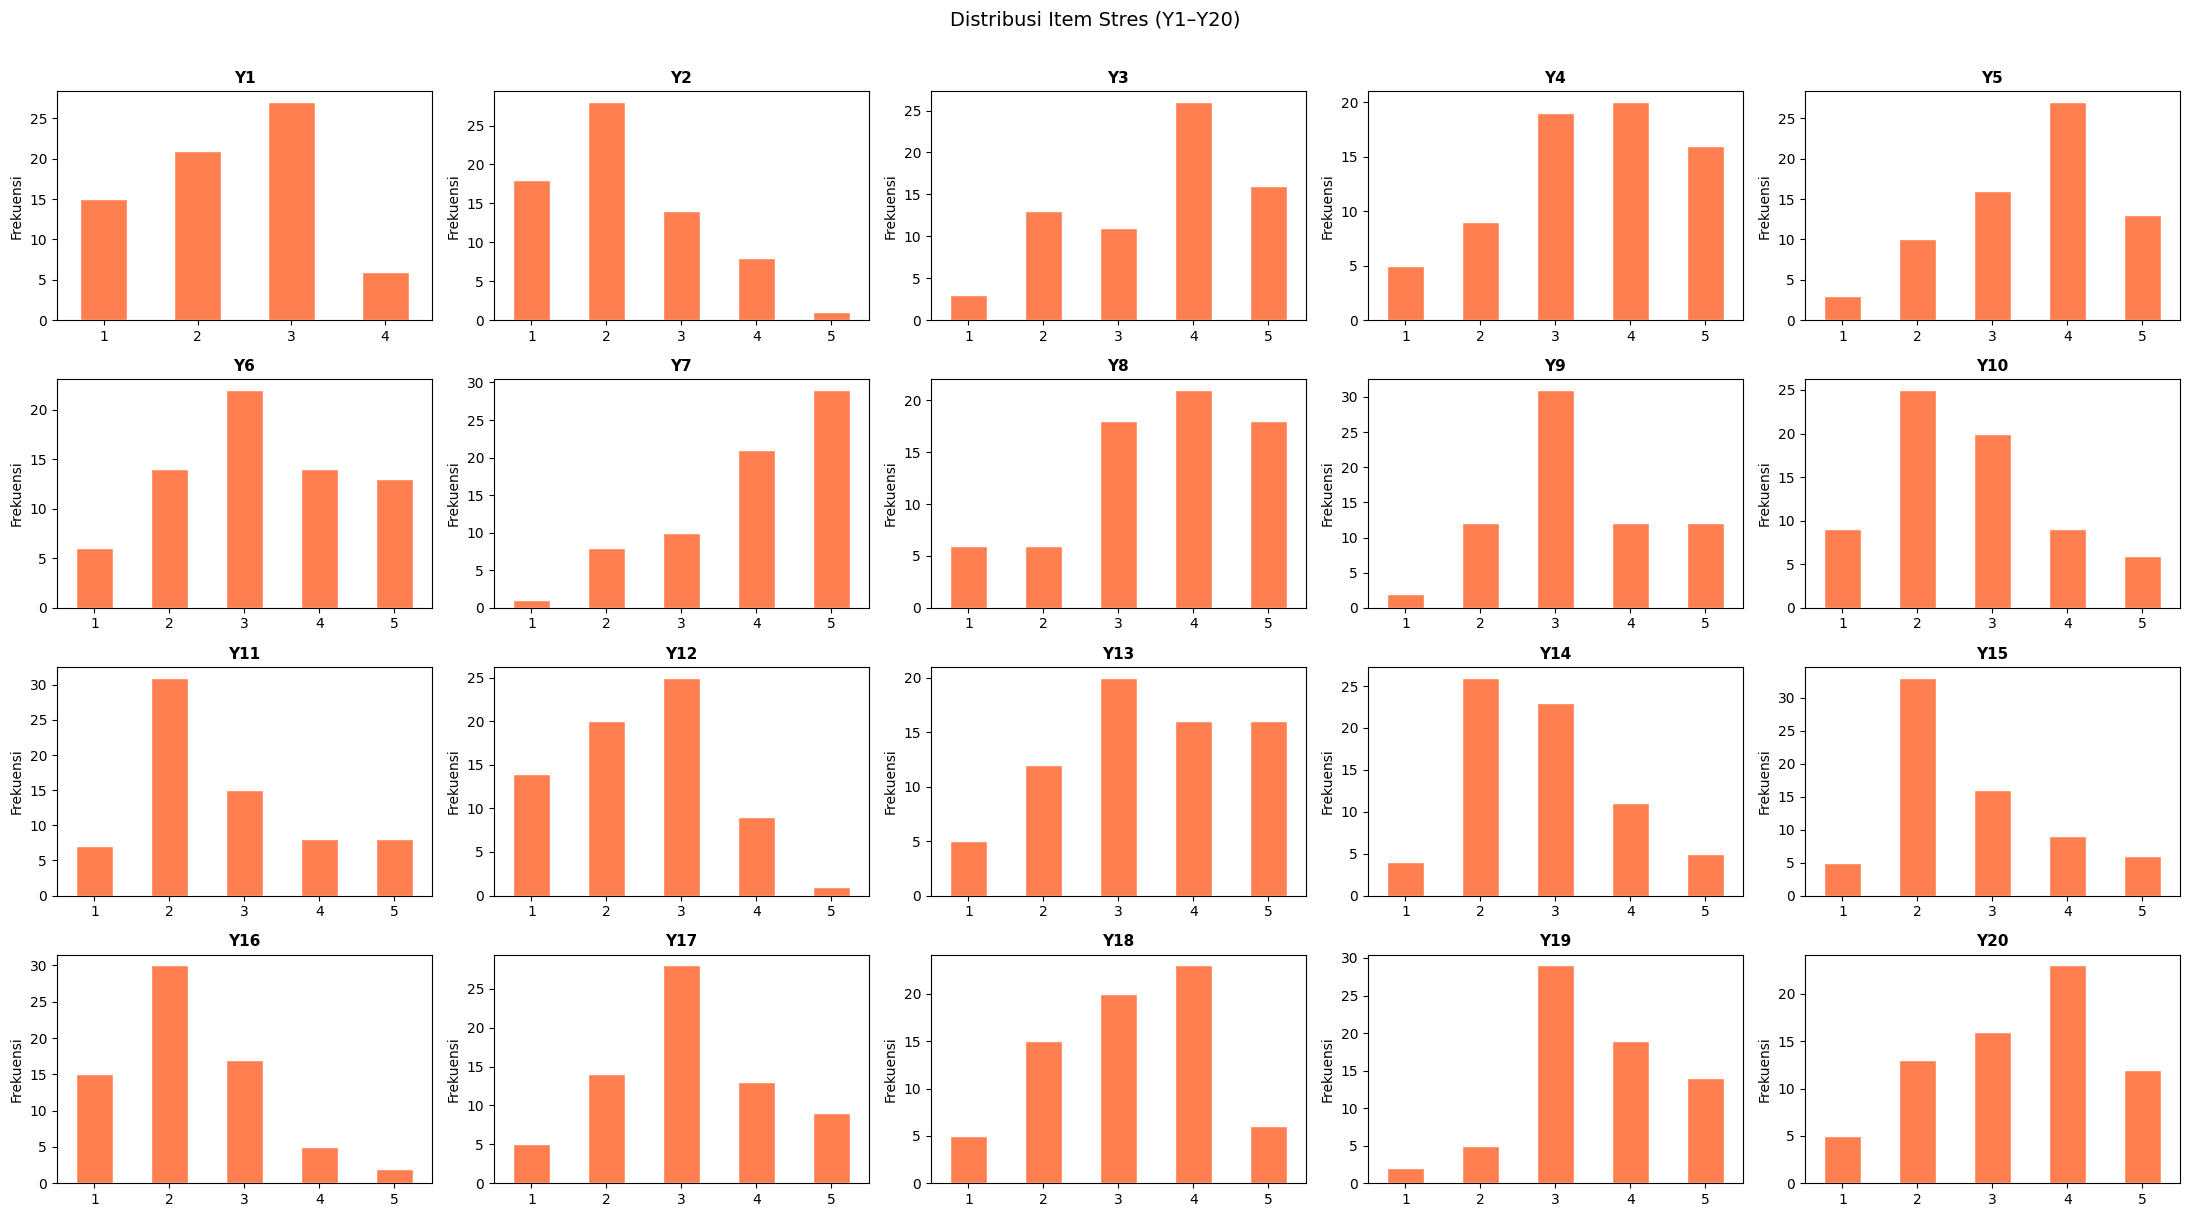

In [171]:
# Distribusi item Y (stres)
fig, axes = plt.subplots(4, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(var_y.columns[:20]):
    var_y[col].value_counts().sort_index().plot(kind='bar', ax=axes[i],
                                                color='coral', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Item Stres (Y1–Y20)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [172]:
item_cols = [f"Y{i}" for i in range(1, 21)]
missing = [c for c in item_cols if c not in var_y.columns]
if missing:
    print(f"Kolom tidak ditemukan: {missing}")
else:
    df_y = var_y.copy()

    # Agregasi — sum dan mean per responden (per baris)
    df_y["skor_total"] = df_y[item_cols].sum(axis=1)
    df_y["skor_mean"]  = df_y[item_cols].mean(axis=1).round(2)

    print(f"Jumlah responden : {len(df_y)}")
    print(f"Range skor total : {df_y['skor_total'].min()} – {df_y['skor_total'].max()}")
    print(f"Range skor mean  : {df_y['skor_mean'].min():.2f} – {df_y['skor_mean'].max():.2f}")
    print(df_y[["skor_total", "skor_mean"]].head())

Jumlah responden : 69
Range skor total : 30 – 93
Range skor mean  : 1.50 – 4.65
   skor_total  skor_mean
0          81       4.05
1          69       3.45
2          65       3.25
3          65       3.25
4          51       2.55


In [173]:
def kategorisasi_y(mean):
    if mean <= 2.0:
        return "Under-Stress"
    elif mean <= 3.0:
        return "Good-Stress"
    elif mean <= 4.0:
        return "Distress"
    else:
        return "Over-Stress"

df_y["kategori"] = df_y["skor_mean"].apply(kategorisasi_y)

dist = df_y["kategori"].value_counts().reindex(
    ["Under-Stress", "Good-Stress", "Distress", "Over-Stress"]
).fillna(0).astype(int)

dist_pct = (dist / len(df_y) * 100).round(1)

print(pd.DataFrame({"Frekuensi": dist, "Persentase (%)": dist_pct}))

              Frekuensi  Persentase (%)
kategori                               
Under-Stress          2             2.9
Good-Stress          36            52.2
Distress             28            40.6
Over-Stress           3             4.3


In [174]:
print("=== SKOR TOTAL (range 20-100) ===")
print(df_y["skor_total"].describe().round(2))

print("\n=== SKOR MEAN (range 1–5) ===")
print(df_y["skor_mean"].describe().round(2))

=== SKOR TOTAL (range 20-100) ===
count    69.00
mean     61.32
std      11.09
min      30.00
25%      55.00
50%      60.00
75%      69.00
max      93.00
Name: skor_total, dtype: float64

=== SKOR MEAN (range 1–5) ===
count    69.00
mean      3.07
std       0.55
min       1.50
25%       2.75
50%       3.00
75%       3.45
max       4.65
Name: skor_mean, dtype: float64


In [175]:
# Interpretasi otomatis dari grand mean
grand_mean_y = df_y["skor_mean"].mean()
kategori_y = kategorisasi_y(grand_mean_y)

print(f"\nGrand mean  : {grand_mean_y:.2f}")
print(f"Interpretasi: Secara keseluruhan, Tingkat Stress Akademik mahasiswa B28 Kemanggisan")
print(f"              berada di kategori '{kategori_y}'")


Grand mean  : 3.07
Interpretasi: Secara keseluruhan, Tingkat Stress Akademik mahasiswa B28 Kemanggisan
              berada di kategori 'Distress'


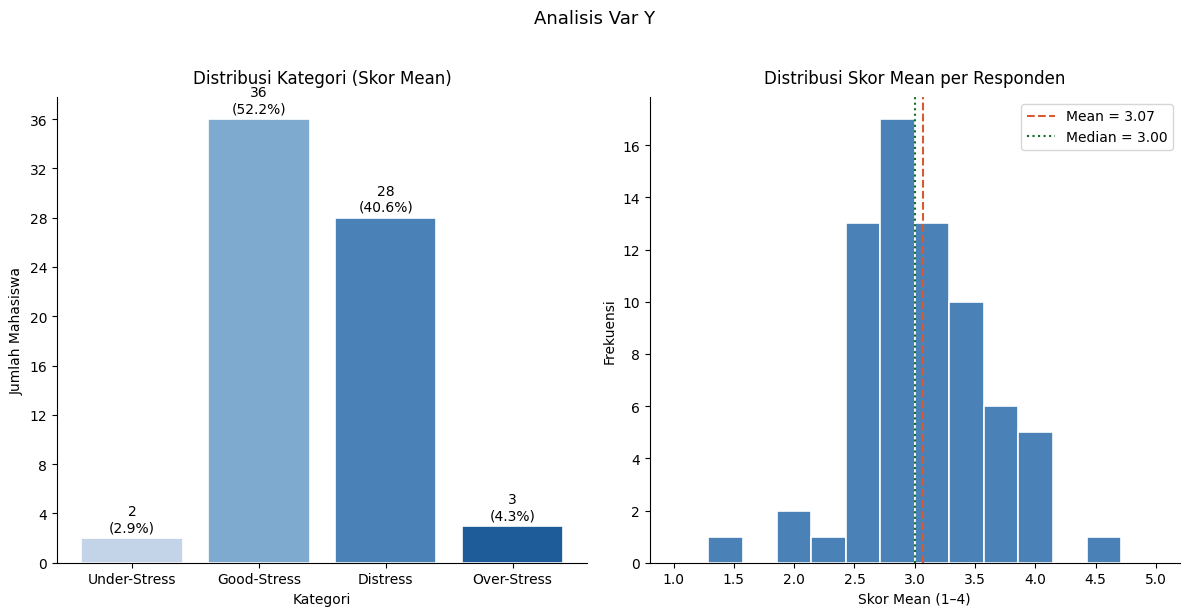

In [176]:
median_val = df_y["skor_mean"].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Chart kiri — distribusi kategori (bar)
kategori_order = ["Under-Stress", "Good-Stress", "Distress", "Over-Stress"]
colors = ["#c4d4e8", "#7faacf", "#4a82b8", "#1d5c99"]

axes[0].bar(kategori_order,
            [dist.get(k, 0) for k in kategori_order],
            color=colors, edgecolor="white", linewidth=1.2)

for i, k in enumerate(kategori_order):
    val = dist.get(k, 0)
    pct = val / len(df_y) * 100
    axes[0].text(i, val + 0.3, f"{val}\n({pct:.1f}%)",
                 ha="center", va="bottom", fontsize=10)

axes[0].set_title("Distribusi Kategori (Skor Mean)", fontsize=12, pad=10)
axes[0].set_ylabel("Jumlah Mahasiswa")
axes[0].set_xlabel("Kategori")
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0].spines[["top", "right"]].set_visible(False)

# Chart kanan — histogram skor mean
axes[1].hist(df_y["skor_mean"], bins=14, range=(1, 5),
             color="#4a82b8", edgecolor="white", linewidth=1.2)
axes[1].axvline(grand_mean_y, color="#d85a30", linewidth=1.5,
                linestyle="--", label=f"Mean = {grand_mean_y:.2f}")
axes[1].axvline(median_val, color="#116d25", linewidth=1.5,
                linestyle=":", label=f"Median = {median_val:.2f}")
axes[1].set_title("Distribusi Skor Mean per Responden", fontsize=12, pad=10)
axes[1].set_ylabel("Frekuensi")
axes[1].set_xlabel("Skor Mean (1–4)")
axes[1].legend(fontsize=10)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Analisis Var Y",
             fontsize=13, fontweight="500", y=1.02)
plt.tight_layout()
plt.show()

In [177]:
item_means = df_y[item_cols].mean().round(2)

print("=== MEAN PER ITEM (diurutkan terendah ke tertinggi) ===")
for item, val in item_means.items():
    bar = "█" * int(val * 5)
    print(f"  {item:4s} : {val:.2f}  {bar}")

=== MEAN PER ITEM (diurutkan terendah ke tertinggi) ===
  Y1   : 2.35  ███████████
  Y2   : 2.22  ███████████
  Y3   : 3.57  █████████████████
  Y4   : 3.48  █████████████████
  Y5   : 3.54  █████████████████
  Y6   : 3.20  ████████████████
  Y7   : 4.00  ████████████████████
  Y8   : 3.57  █████████████████
  Y9   : 3.29  ████████████████
  Y10  : 2.68  █████████████
  Y11  : 2.70  █████████████
  Y12  : 2.46  ████████████
  Y13  : 3.38  ████████████████
  Y14  : 2.81  ██████████████
  Y15  : 2.68  █████████████
  Y16  : 2.26  ███████████
  Y17  : 3.10  ███████████████
  Y18  : 3.14  ███████████████
  Y19  : 3.55  █████████████████
  Y20  : 3.35  ████████████████


## 5. Feature Engineering

In [178]:
# --- Target utama: rata-rata 20 item Y ---
df['target'] = var_y.sum(axis=1) / 20.0

# --- Faktor-faktor Y ---
for faktor, items in FAKTOR_MAP.items():
    df[faktor] = var_y[items].sum(axis=1) / float(len(items))

# --- Skor efikasi diri agregat ---
df['Efikasi Diri'] = df[X_ITEM_COLS].sum(axis=1) / 10.0

print('Kolom setelah feature engineering:')
print(list(df.columns))

Kolom setelah feature engineering:
['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'target', 'Y - Faktor 2', 'Y - Faktor 3', 'Y - Faktor 5', 'Y - Faktor 6', 'Y - Faktor 7', 'Efikasi Diri']


In [179]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,target,Y - Faktor 2,Y - Faktor 3,Y - Faktor 5,Y - Faktor 6,Y - Faktor 7,Efikasi Diri
count,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000
mean,3.362319,3.043478,2.710145,2.695652,2.739130,3.289855,2.855072,2.942029,2.927536,2.898551,3.065942,3.028986,3.514493,2.804348,2.584541,3.286232,2.946377
std,0.568047,0.736342,0.709214,0.713408,0.678497,0.620755,0.670280,0.683504,0.671233,0.597665,0.554427,0.784613,0.781077,0.797364,0.840957,0.825017,0.466394
min,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.500000,1.000000,1.750000,1.000000,1.000000,1.000000,1.800000
25%,3.000000,3.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.750000,2.600000,3.000000,2.250000,2.000000,2.750000,2.600000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.200000,3.500000,2.750000,2.333333,3.250000,2.900000
75%,4.000000,4.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.450000,3.400000,4.000000,3.250000,3.000000,3.750000,3.200000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.650000,4.600000,5.000000,4.750000,5.000000,5.000000,4.000000


In [180]:
FAKTOR_COLS = list(FAKTOR_MAP.keys())

# Model 1 — 10 item X + Kelas + Gender → target (Y mean)
df_1 = df.drop(columns=FAKTOR_COLS + ['Efikasi Diri'])

# Model 2 — X_mean + Kelas + Gender → target (Y mean)
df_2 = df.drop(columns=X_ITEM_COLS + FAKTOR_COLS)

# Model 3 — X_mean + Kelas + Gender → tiap Faktor Y (5 model)
df_3 = df.drop(columns=X_ITEM_COLS + ['target'])

for label, d in [('df_1', df_1), ('df_2', df_2), ('df_3', df_3)]:
    print(f'{label}: {d.shape}  |  kolom: {list(d.columns)}')
    print()

df_1: (69, 13)  |  kolom: ['Kelas', 'Gender', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'target']

df_2: (69, 4)  |  kolom: ['Kelas', 'Gender', 'target', 'Efikasi Diri']

df_3: (69, 8)  |  kolom: ['Kelas', 'Gender', 'Y - Faktor 2', 'Y - Faktor 3', 'Y - Faktor 5', 'Y - Faktor 6', 'Y - Faktor 7', 'Efikasi Diri']



In [181]:
print("Variabel X (Mean Keseluruhan Item):", df['Efikasi Diri'].mean().round(2))
print("Variabel X (Std Keseluruhan Item):", df['Efikasi Diri'].std().round(2))
print("Variabel Y (Mean Keseluruhan Item):", df['target'].mean().round(2))
print("Variabel Y (Std Keseluruhan Item):", df['target'].std().round(2))

Variabel X (Mean Keseluruhan Item): 2.95
Variabel X (Std Keseluruhan Item): 0.47
Variabel Y (Mean Keseluruhan Item): 3.07
Variabel Y (Std Keseluruhan Item): 0.55


## 6. Helper Functions

In [182]:
def build_pipeline() -> Pipeline:
    """Buat pipeline LinearRegression dengan OHE untuk kolom kategoris."""
    prep = ColumnTransformer([
        ('ohe',   OneHotEncoder(drop='first', sparse_output=False), OHE_COLS),
        ('pass',  'passthrough', slice(len(OHE_COLS), None))          # kolom numerik sisanya
    ])
    return Pipeline([('preprocessor', prep), ('lr', LinearRegression())])


def fit_and_evaluate(pipeline: Pipeline, X: pd.DataFrame, y: pd.Series,
                     label: str = '', cv: int = 5) -> dict:
    """Fit model, hitung metrik in-sample & CV-R², kembalikan dict hasil."""
    pipeline.fit(X, y)
    y_pred = pipeline.predict(X)
    
    r2 = pipeline.score(X, y)
    
    cv_r2 = cross_val_score(pipeline, X, y, cv=cv, scoring='r2').mean()

    result = {
        'Label'  : label,
        'MAE'    : round(mean_absolute_error(y, y_pred),  4),
        'MSE'    : round(mean_squared_error(y, y_pred),   4),
        'RMSE'   : round(np.sqrt(mean_squared_error(y, y_pred)), 4),
        'R²'     : round(r2_score(y, y_pred),             4),
        'CV-R²'  : round(cv_r2,                           4),
    }
    return result, y_pred, r2


def get_coef_df(pipeline: Pipeline, X: pd.DataFrame) -> pd.DataFrame:
    """Ambil nama fitur & koefisien dari pipeline yang sudah di-fit."""
    # Dapatkan nama fitur output dari preprocessor
    try:
        ohe_names  = pipeline.named_steps['preprocessor']\
                         .named_transformers_['ohe']\
                         .get_feature_names_out(OHE_COLS)
    except Exception:
        ohe_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

    num_cols   = [c for c in X.columns if c not in OHE_COLS]
    feat_names = list(ohe_names) + num_cols

    coef = pipeline.named_steps['lr'].coef_
    intercept = pipeline.named_steps['lr'].intercept_
    return pd.DataFrame({'Fitur': feat_names[:len(coef)],
                         'Koefisien (×100)': (coef[:len(feat_names)] * 100).round(2)})\
             .sort_index(), intercept


def print_metrics(result: dict):
    print(f"  MAE   : {result['MAE']}")
    print(f"  MSE   : {result['MSE']}")
    print(f"  RMSE  : {result['RMSE']}")
    print(f"  R²    : {result['R²']}")
    print(f"  CV-R² : {result['CV-R²']}  (5-fold)")


print('✅ Helper functions siap.')

✅ Helper functions siap.


## 7. Model 1 — 10 Item X + Kelas + Gender → Y Mean

$$Y = \beta_0 + \beta_1 X_1 + \cdots + \beta_{10} X_{10} + \beta_{11}\,\text{Kelas} + \beta_{12}\,\text{Gender}$$

In [183]:
X1 = df_1.drop(columns=['target'])
y1 = df_1['target']

# Reorder: OHE_COLS dulu, lalu numerik
X1 = X1[OHE_COLS + [c for c in X1.columns if c not in OHE_COLS]]

pipe1    = build_pipeline()
result1, y_pred1, r2_1  = fit_and_evaluate(pipe1, X1, y1, label='Model 1')

print('=== Model 1 – Metrik ===')
print_metrics(result1)

=== Model 1 – Metrik ===
  MAE   : 0.3419
  MSE   : 0.2035
  RMSE  : 0.4512
  R²    : 0.3281
  CV-R² : -0.392  (5-fold)


In [184]:
coef1, intercept1 = get_coef_df(pipe1, X1)
print('=== Model 1 – Koefisien ===')
display(coef1)
print("Intercept:", intercept1.round(2))

=== Model 1 – Koefisien ===


,Fitur,Koefisien (×100)
0,Gender_Wanita,16.35
1,Kelas_LB09,6.08
2,Kelas_LC09,13.85
3,Kelas_LD09,-3.50
4,Kelas_LE09,-10.06
5,X1,38.58
6,X2,-0.76
7,X3,-17.45
8,X4,6.51
9,X5,6.77


Intercept: 3.78


$$Y = 3.73 + 37.99 X_1 + \cdots - 25.56 X_{10} + 5.32 D_{LB09} + 15.46 D_{LC09} - 4.46 D_{LD09} - 9.82 D_{LE09} + 17.86 D_{Wanita}$$

## 8. Model 2 — X Mean + Kelas + Gender → Y Mean

$$Y_{\text{mean}} = \beta_0 + \beta_1\,X_{\text{mean}} + \beta_2\, D_{\text{Kelas}} + \beta_3\,D_{\text{Gender}}$$

In [185]:
X2 = df_2.drop(columns=['target'])
y2 = df_2['target']

X2 = X2[OHE_COLS + [c for c in X2.columns if c not in OHE_COLS]]

pipe2   = build_pipeline()
result2, y_pred2, r2_2 = fit_and_evaluate(pipe2, X2, y2, label='Model 2')

print('=== Model 2 – Metrik ===')
print_metrics(result2)

=== Model 2 – Metrik ===
  MAE   : 0.3904
  MSE   : 0.2538
  RMSE  : 0.5038
  R²    : 0.1621
  CV-R² : -0.0589  (5-fold)


In [186]:
coef2, intercept2 = get_coef_df(pipe2, X2)
print('=== Model 2 – Koefisien ===')
display(coef2)
print("Intercept:", intercept2.round(2))

=== Model 2 – Koefisien ===


,Fitur,Koefisien (×100)
0,Gender_Wanita,16.46
1,Kelas_LB09,0.78
2,Kelas_LC09,27.04
3,Kelas_LD09,-2.09
4,Kelas_LE09,-11.44
5,Efikasi Diri,-40.05


Intercept: 4.15


$$Y = 4.15 - 16.02 X_{mean} + 0.78 D_{LB09} + 27.04 D_{LC09} - 2.09 D_{LD09} - 11.44 D_{LE09} + 16.46 D_{Wanita}$$

$$Y_{mean} = \beta_0\ - \beta_1\ X_{mean} + \beta_2\ D_{LB09} + \beta_3\ D_{LC09} - \beta_4\ D_{LD09} - \beta_5\ D_{LE09} + \beta_6\ D_{Wanita}$$

## 9. Model 3 — X Mean + Kelas + Gender → Tiap Faktor Y

$$Y_{\text{faktor}_k} = \beta_0 + \beta_1\,X_{\text{mean}} + \beta_2\, D_{\text{Kelas}} + \beta_3\,D_{\text{Gender}}, \quad k \in \{2,3,5,6,7\}$$

In [187]:
X3 = df_3.drop(columns=FAKTOR_COLS)
X3 = X3[OHE_COLS + [c for c in X3.columns if c not in OHE_COLS]]

results3 = {}   # faktor → dict hasil
pipes3   = {}   # faktor → pipeline yang sudah fit

for faktor in FAKTOR_COLS:
    y_k        = df_3[faktor]
    pipe_k     = build_pipeline()
    result_k, y_pred3, r2_3 = fit_and_evaluate(pipe_k, X3, y_k, label=faktor)
    results3[faktor] = result_k
    pipes3[faktor]   = pipe_k
    print(f'\n=== {faktor} ===')
    print_metrics(result_k)


=== Y - Faktor 2 ===
  MAE   : 0.5537
  MSE   : 0.5118
  RMSE  : 0.7154
  R²    : 0.1564
  CV-R² : -0.1487  (5-fold)

=== Y - Faktor 3 ===
  MAE   : 0.6185
  MSE   : 0.537
  RMSE  : 0.7328
  R²    : 0.1068
  CV-R² : -0.2392  (5-fold)

=== Y - Faktor 5 ===
  MAE   : 0.6173
  MSE   : 0.5953
  RMSE  : 0.7716
  R²    : 0.0499
  CV-R² : -0.4764  (5-fold)

=== Y - Faktor 6 ===
  MAE   : 0.6217
  MSE   : 0.6618
  RMSE  : 0.8135
  R²    : 0.0504
  CV-R² : -0.2973  (5-fold)

=== Y - Faktor 7 ===
  MAE   : 0.5375
  MSE   : 0.536
  RMSE  : 0.7321
  R²    : 0.2009
  CV-R² : 0.0388  (5-fold)


In [188]:
# Koefisien masing-masing sub-model
for faktor, pipe_k in pipes3.items():
    print(f'\n--- Koefisien: {faktor} ---')
    coef3, intercept3 = get_coef_df(pipe_k, X3)
    display(coef3)
    print("Intercept:", intercept3.round(2))


--- Koefisien: Y - Faktor 2 ---


,Fitur,Koefisien (×100)
0,Gender_Wanita,12.10
1,Kelas_LB09,-4.64
2,Kelas_LC09,49.12
3,Kelas_LD09,11.99
4,Kelas_LE09,2.83
5,Efikasi Diri,-56.43


Intercept: 4.55

--- Koefisien: Y - Faktor 3 ---


,Fitur,Koefisien (×100)
0,Gender_Wanita,37.18
1,Kelas_LB09,3.68
2,Kelas_LC09,30.06
3,Kelas_LD09,14.37
4,Kelas_LE09,-8.70
5,Efikasi Diri,-34.66


Intercept: 4.35

--- Koefisien: Y - Faktor 5 ---


...

Intercept: 3.02

--- Koefisien: Y - Faktor 6 ---


,Fitur,Koefisien (×100)
0,Gender_Wanita,-2.53
1,Kelas_LB09,21.37
2,Kelas_LC09,25.26
3,Kelas_LD09,-17.53
4,Kelas_LE09,-8.59
5,Efikasi Diri,-28.60


Intercept: 3.33

--- Koefisien: Y - Faktor 7 ---


,Fitur,Koefisien (×100)
0,Gender_Wanita,8.34
1,Kelas_LB09,-40.73
2,Kelas_LC09,8.11
3,Kelas_LD09,-48.05
4,Kelas_LE09,-60.53
5,Efikasi Diri,-57.87


Intercept: 5.2


$$Y_{\text{faktor}_k} = \beta_0 + \beta_1 X_{mean} + \beta_2 D_{LB09} + \beta_3 D_{LC09} + \beta_4 D_{LD09} + \beta_5 D_{LE09} + \beta_6 D_{Wanita}, \quad k \in \{2,3,5,6,7\}$$

## 10. Perbandingan Semua Model

In [189]:
# Kumpulkan semua hasil
all_results = [result1, result2] + list(results3.values())
comparison_df = pd.DataFrame(all_results).set_index('Label')

print('=== Tabel Perbandingan Metrik ===')
display(comparison_df.style
    .background_gradient(subset=['R²', 'CV-R²'], cmap='RdYlGn')
    .background_gradient(subset=['MAE', 'RMSE'],  cmap='RdYlGn_r')
    .format('{:.4f}')
)

=== Tabel Perbandingan Metrik ===


,MAE,MSE,RMSE,R²,CV-R²
Label,,,,,
Model 1,0.3419,0.2035,0.4512,0.3281,-0.3920
Model 2,0.3904,0.2538,0.5038,0.1621,-0.0589
Y - Faktor 2,0.5537,0.5118,0.7154,0.1564,-0.1487
Y - Faktor 3,0.6185,0.5370,0.7328,0.1068,-0.2392
Y - Faktor 5,0.6173,0.5953,0.7716,0.0499,-0.4764
Y - Faktor 6,0.6217,0.6618,0.8135,0.0504,-0.2973
Y - Faktor 7,0.5375,0.5360,0.7321,0.2009,0.0388


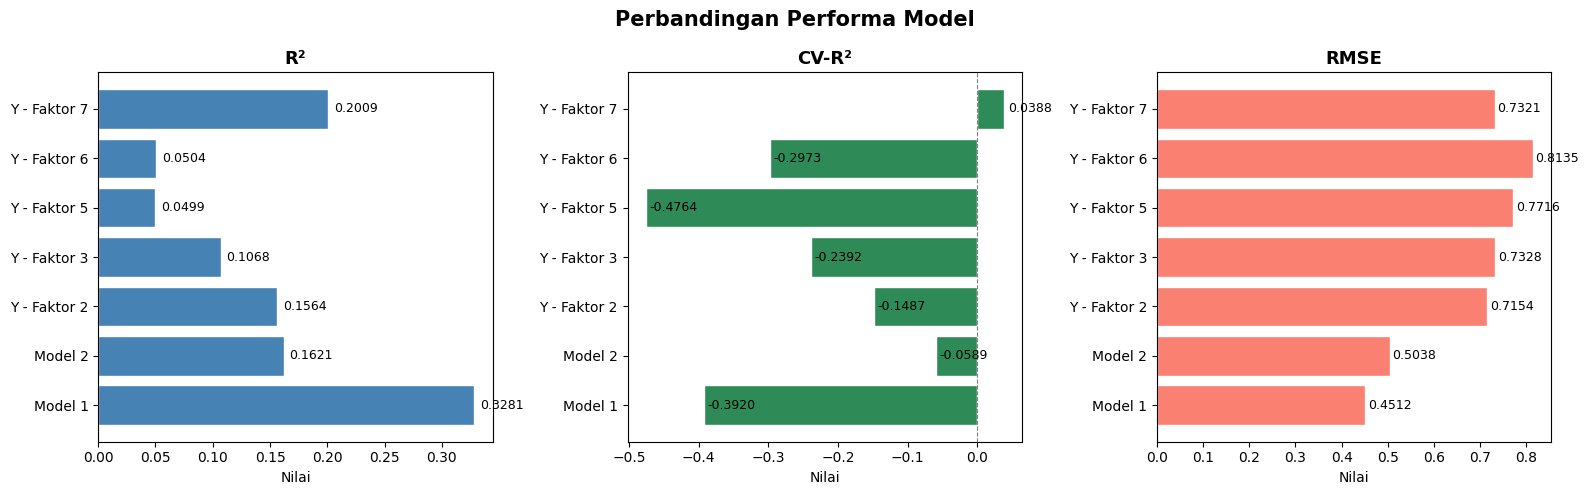

In [190]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ['R²', 'CV-R²', 'RMSE']
colors = ['steelblue', 'seagreen', 'salmon']

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    vals   = comparison_df[metric]
    bars   = ax.barh(vals.index, vals.values, color=color, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Perbandingan Performa Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

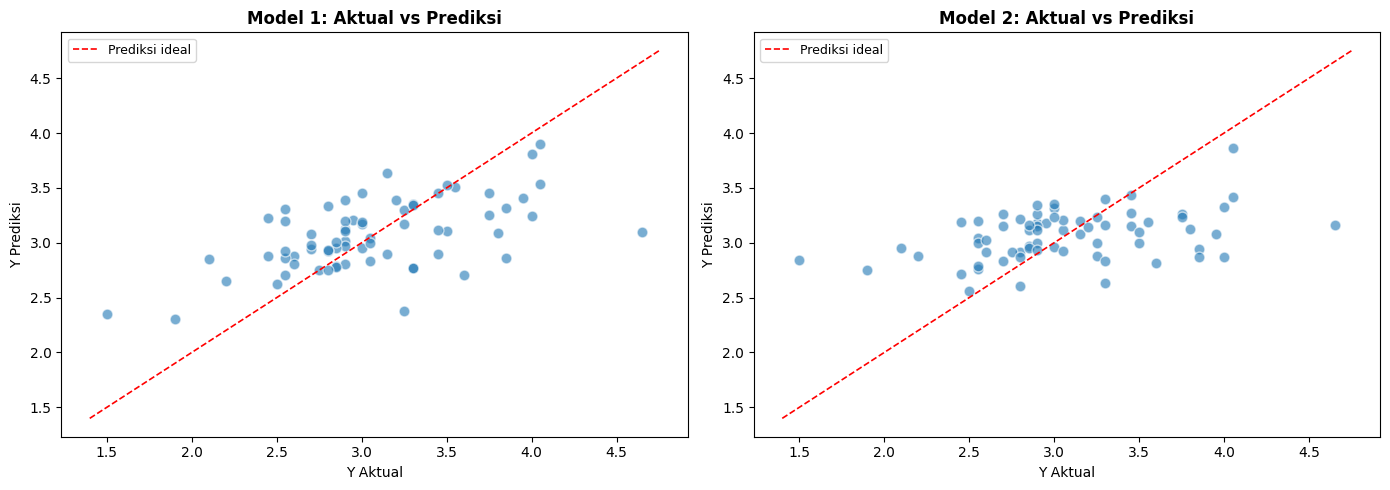

In [191]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, pipe, X_used, y_used) in zip(
        axes,
        [('Model 1', pipe1, X1, y1),
         ('Model 2', pipe2, X2, y2)]):

    y_pred = pipe.predict(X_used)
    ax.scatter(y_used, y_pred, alpha=0.6, edgecolors='w', s=60)
    lims = [min(y_used.min(), y_pred.min()) - 0.1, max(y_used.max(), y_pred.max()) + 0.1]
    ax.plot(lims, lims, 'r--', linewidth=1.2, label='Prediksi ideal')
    ax.set_title(f'{label}: Aktual vs Prediksi', fontsize=12, fontweight='bold')
    ax.set_xlabel('Y Aktual')
    ax.set_ylabel('Y Prediksi')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 11. Ringkasan & Rekomendasi

Gunakan tabel di bawah sebagai panduan memilih model yang sesuai dengan tujuan analisis.

| Model | Kelebihan | Keterbatasan | Cocok untuk |
|-------|-----------|--------------|-------------|
| **Model 1** | Detail pengaruh tiap item X | Banyak prediktor → risiko overfitting dengan n kecil | Eksplorasi pengaruh per item |
| **Model 2** | Parsimonious, interpretasi mudah | Kehilangan variasi antar item | Laporan & presentasi |
| **Model 3** | Pengaruh X terhadap tiap dimensi Y  (Bonferroni Correction) | Lima model terpisah sulit dibandingkan langsung | Analisis per faktor stres |

## Asumsi Regresi

**Panduan interpretasi cepat:**
| Uji | Indikator aman |
|---|---|
| Shapiro-Wilk | p > 0.05 |
| Breusch-Pagan | p > 0.05 |
| VIF | < 10 (idealnya < 5) |
| Durbin-Watson | 1.5 – 2.5 |

Shapiro-Wilk: p=0.0235


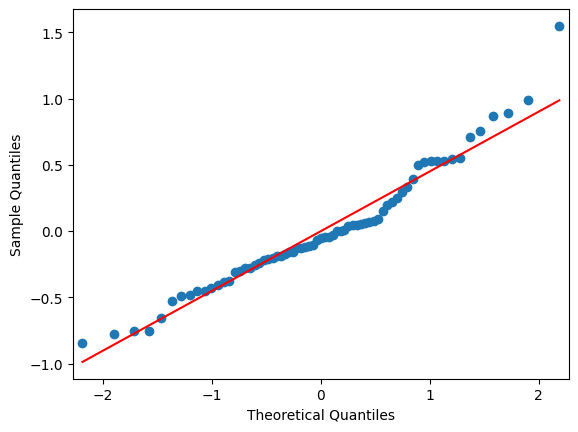

Breusch-Pagan: p=0.3564


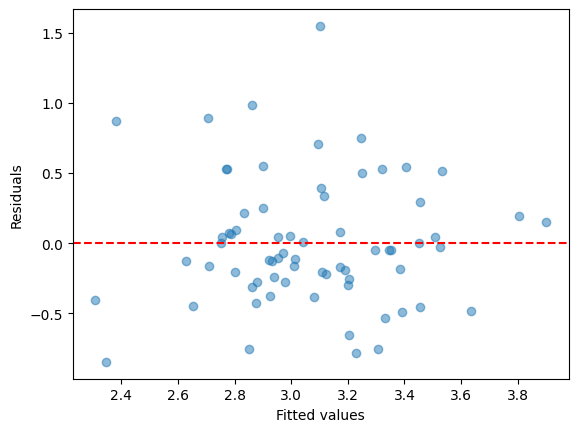

          Feature        VIF
0              X1  69.216553
1              X2  26.758914
2              X3  45.263684
3              X4  36.669196
4              X5  37.076323
5              X6  57.375225
6              X7  40.518998
7              X8  65.059983
8              X9  65.628891
9             X10  60.247909
10  Gender_Wanita   1.659407
11     Kelas_LB09   2.697621
12     Kelas_LC09   2.232147
13     Kelas_LD09   1.837501
14     Kelas_LE09   1.524496
Durbin-Watson: 2.2531


In [192]:
resid1 = y1 - y_pred1

# Uji Normalitas
stat1, p1 = stats.shapiro(resid1)
print(f"Shapiro-Wilk: p={p1:.4f}")

sm.qqplot(resid1, line='s')  # butuh statsmodels untuk Q-Q plot
plt.show()

X1_encoded = pd.get_dummies(X1, columns=['Gender', 'Kelas'], drop_first=True)
X1_encoded = X1_encoded.astype(float)

# # Cek hasilnya
# print(X1_encoded.dtypes)
# print(X1_encoded.head())

X_const1 = sm.add_constant(X1_encoded)
lm1, lm_p1, _1, _ = het_breuschpagan(resid1, X_const1)
print(f"Breusch-Pagan: p={lm_p1:.4f}")

# Plot residual vs fitted
plt.scatter(y_pred1, resid1, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values"); plt.ylabel("Residuals")
plt.show()

X_df = pd.DataFrame(X1_encoded)  # pastikan bentuk DataFrame
vif1 = pd.DataFrame({
    "Feature": X_df.columns,
    "VIF": [variance_inflation_factor(X_df.values, i)
            for i in range(X_df.shape[1])]
})
print(vif1)

dw1 = durbin_watson(resid1)
print(f"Durbin-Watson: {dw1:.4f}")

Shapiro-Wilk: p=0.1980


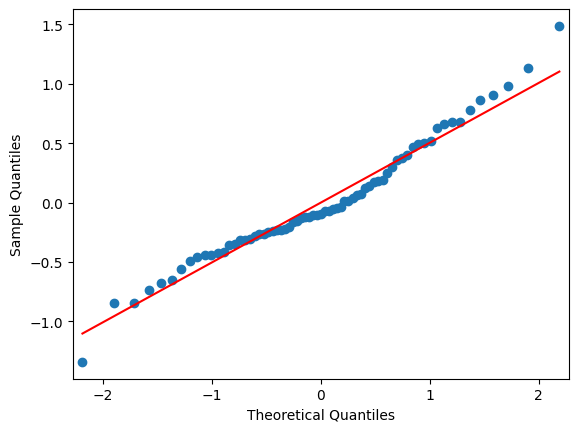

Breusch-Pagan: p=0.0530


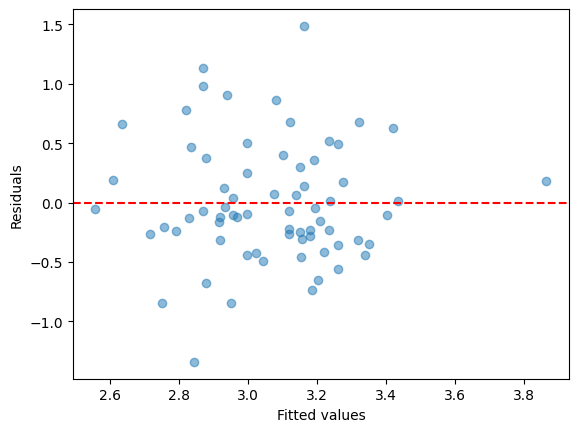

         Feature       VIF
0   Efikasi Diri  4.584200
1  Gender_Wanita  1.428683
2     Kelas_LB09  2.378172
3     Kelas_LC09  1.978053
4     Kelas_LD09  1.321706
5     Kelas_LE09  1.459078
Durbin-Watson: 2.0289


In [193]:
resid2 = y2 - y_pred2

# Uji Normalitas
stat2, p2 = stats.shapiro(resid2)
print(f"Shapiro-Wilk: p={p2:.4f}")

sm.qqplot(resid2, line='s')  # butuh statsmodels untuk Q-Q plot
plt.show()

X2_encoded = pd.get_dummies(X2, columns=['Gender', 'Kelas'], drop_first=True)
X2_encoded = X2_encoded.astype(float)

# # Cek hasilnya
# print(X2_encoded.dtypes)
# print(X2_encoded.head())

X_const2 = sm.add_constant(X2_encoded)
lm2, lm_p2, _2, _ = het_breuschpagan(resid2, X_const2)
print(f"Breusch-Pagan: p={lm_p2:.4f}")

# Plot residual vs fitted
plt.scatter(y_pred2, resid2, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values"); plt.ylabel("Residuals")
plt.show()

X_df = pd.DataFrame(X2_encoded)  # pastikan bentuk DataFrame
vif2 = pd.DataFrame({
    "Feature": X_df.columns,
    "VIF": [variance_inflation_factor(X_df.values, i)
            for i in range(X_df.shape[1])]
})
print(vif2)

dw2 = durbin_watson(resid2)
print(f"Durbin-Watson: {dw2:.4f}")

In [194]:
print("R-squared:", r2_2)

# Adjusted R-squared
n = X2_encoded.shape[0]  # jumlah observasi
k = X2_encoded.shape[1]  # jumlah prediktor
adj_r2 = 1 - (1 - r2_2) * (n - 1) / (n - k - 1)
print("Adj R-squared:", adj_r2)

# F-statistic dan p-value (hitung manual)
f_stat = (r2_2 / k) / ((1 - r2_2) / (n - k - 1))
p_value_f = 1 - stats.f.cdf(f_stat, k, n - k - 1)
print("F-statistic:", f_stat)
print("Prob (F-statistic):", p_value_f)

R-squared: 0.1620504990447572
Adj R-squared: 0.0809586118555401
F-statistic: 1.9983564899240058
Prob (F-statistic): 0.07936311913980987


In [195]:
print("n:", n)
print("k:", k)
print("shape X:", X2.shape)

n: 69
k: 6
shape X: (69, 3)


In [196]:
X2_ = sm.add_constant(X2_encoded)  # tambah intercept

model = sm.OLS(y2, X2_).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     1.998
Date:                Tue, 16 Jun 2026   Prob (F-statistic):             0.0794
Time:                        17:47:33   Log-Likelihood:                -50.606
No. Observations:                  69   AIC:                             115.2
Df Residuals:                      62   BIC:                             130.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.1515      0.429      9.684

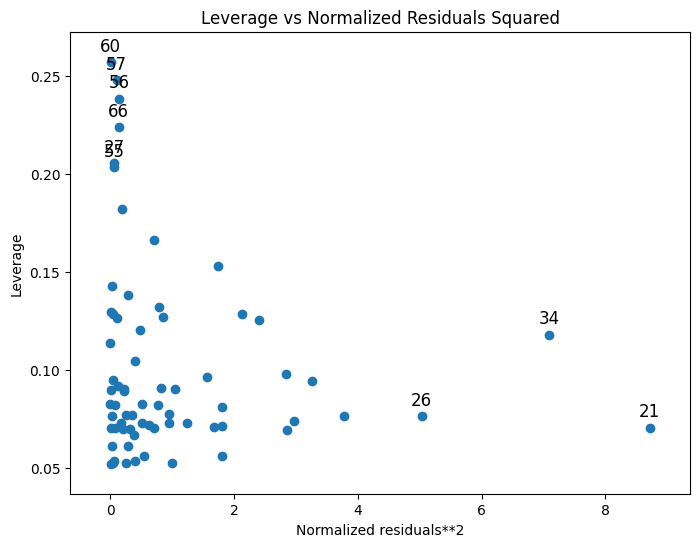

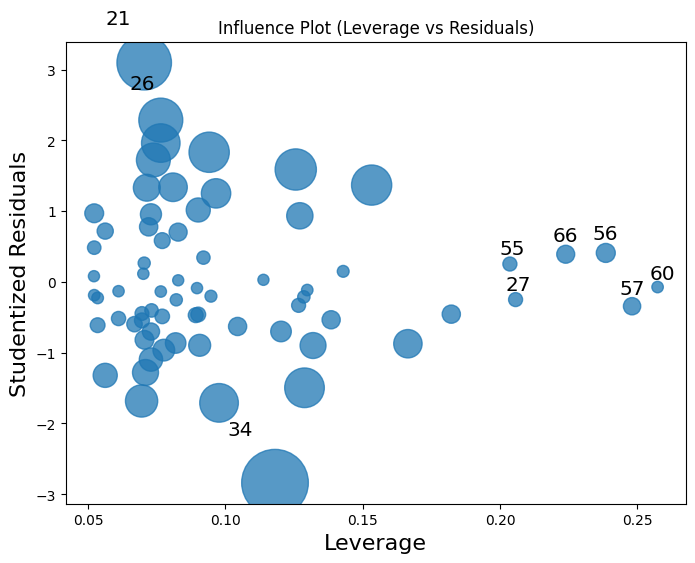

In [197]:
fig, ax = plt.subplots(figsize=(8, 6), num=1)
sm.graphics.plot_leverage_resid2(model, ax=ax) 
plt.title("Leverage vs Normalized Residuals Squared")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6), num=2)
sm.graphics.influence_plot(model, ax=ax)
plt.title("Influence Plot (Leverage vs Residuals)")
plt.show()

$$Y = 4.15 - 0.1602 X_{mean} + 0.0078 D_{LB09} + 0.2704 D_{LC09} - 0.0209 D_{LD09} - 0.1144 D_{LE09} + 0.1646 D_{Wanita} + \epsilon\$$

## Test

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import r2_score

In [199]:
def evaluate_regression(y_true, y_pred, X, model_name="Model"):
    resid = y_true - y_pred

    print("="*50)
    print(model_name)
    print("="*50)

    # Normalitas
    stat, p = stats.shapiro(resid)
    print(f"Shapiro-Wilk p-value : {p:.4f}")

    sm.qqplot(resid, line='s')
    plt.title(f"QQ Plot")
    plt.show()

    # Encode variabel kategorikal
    X_encoded = pd.get_dummies(
        X,
        columns=['Kelas', 'Gender'],
        drop_first=True
    ).astype(float)

    X_const = sm.add_constant(X_encoded)

    # Heteroskedastisitas
    lm, lm_p, fvalue, fpvalue = het_breuschpagan(
        resid,
        X_const
    )

    print(f"Breusch-Pagan p-value : {lm_p:.4f}")

    # Residual Plot
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, resid, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot")
    plt.show()

    # VIF
    vif = pd.DataFrame({
        "Feature": X_encoded.columns,
        "VIF": [
            variance_inflation_factor(
                X_encoded.values, i
            )
            for i in range(X_encoded.shape[1])
        ]
    })

    print("\nVIF")
    print(vif)

    # Durbin Watson
    dw = durbin_watson(resid)
    print(f"\nDurbin-Watson : {dw:.4f}")

    return {
        "Shapiro_p": p,
        "BP_p": lm_p,
        "DW": dw,
        "Max_VIF": vif["VIF"].max()
    }

Model 1
Shapiro-Wilk p-value : 0.0235


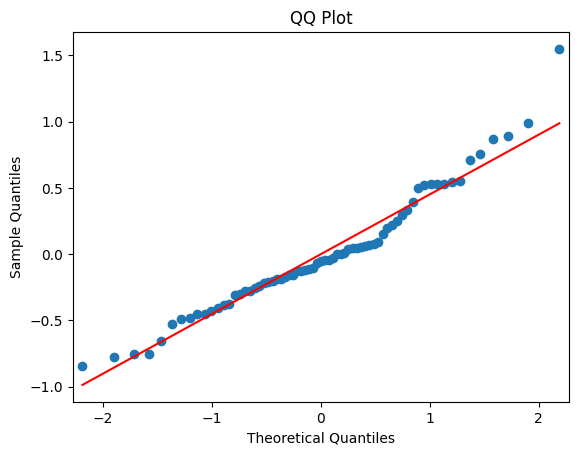

Breusch-Pagan p-value : 0.3564


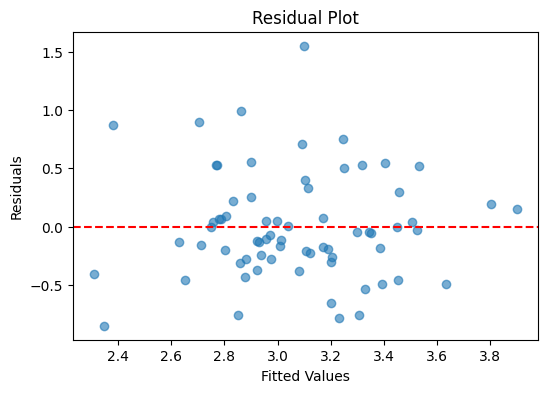


VIF
          Feature        VIF
0              X1  69.216553
1              X2  26.758914
2              X3  45.263684
3              X4  36.669196
4              X5  37.076323
5              X6  57.375225
6              X7  40.518998
7              X8  65.059983
8              X9  65.628891
9             X10  60.247909
10     Kelas_LB09   2.697621
11     Kelas_LC09   2.232147
12     Kelas_LD09   1.837501
13     Kelas_LE09   1.524496
14  Gender_Wanita   1.659407

Durbin-Watson : 2.2531


In [200]:
result1 = evaluate_regression(
    y1,
    y_pred1,
    X1,
    model_name="Model 1"
)

Model 2
Shapiro-Wilk p-value : 0.1980


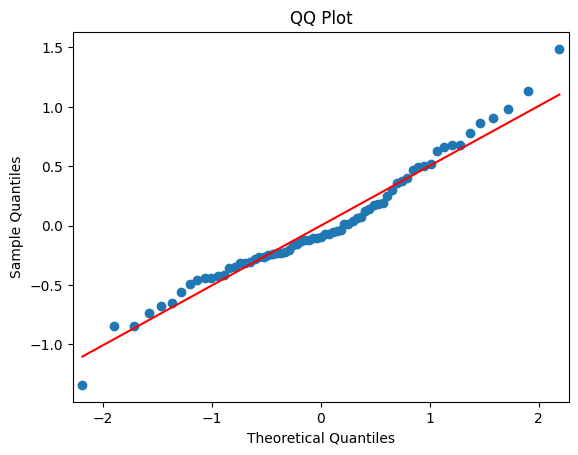

Breusch-Pagan p-value : 0.0530


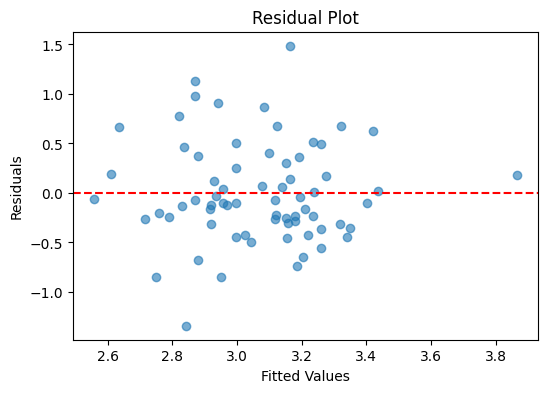


VIF
         Feature       VIF
0   Efikasi Diri  4.584200
1     Kelas_LB09  2.378172
2     Kelas_LC09  1.978053
3     Kelas_LD09  1.321706
4     Kelas_LE09  1.459078
5  Gender_Wanita  1.428683

Durbin-Watson : 2.0289


In [201]:
result2 = evaluate_regression(
    y2,
    y_pred2,
    X2,
    model_name="Model 2"
)

In [202]:
X2_encoded = pd.get_dummies(
    X2,
    columns=['Gender', 'Kelas'],
    drop_first=True
).astype(float)

X2_sm = sm.add_constant(X2_encoded)

model2 = sm.OLS(y2, X2_sm).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     1.998
Date:                Tue, 16 Jun 2026   Prob (F-statistic):             0.0794
Time:                        17:47:35   Log-Likelihood:                -50.606
No. Observations:                  69   AIC:                             115.2
Df Residuals:                      62   BIC:                             130.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.1515      0.429      9.684

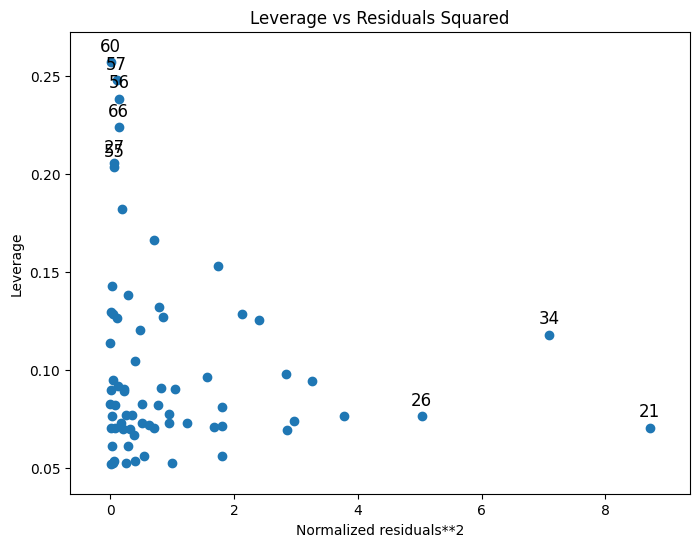

In [203]:
fig, ax = plt.subplots(figsize=(8,6))
sm.graphics.plot_leverage_resid2(model2, ax=ax)
plt.title("Leverage vs Residuals Squared")
plt.show()

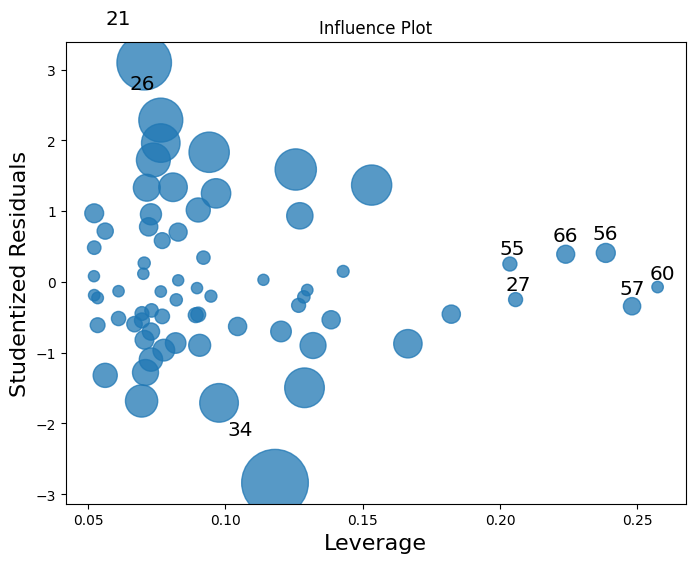

In [204]:
fig, ax = plt.subplots(figsize=(8,6))
sm.graphics.influence_plot(model2, ax=ax)
plt.title("Influence Plot")
plt.show()

In [205]:
comparison = pd.DataFrame({
    "Metric": [
        "Shapiro-Wilk p",
        "Breusch-Pagan p",
        "Durbin-Watson",
        "Max VIF"
    ],
    "Model 1": [
        result1["Shapiro_p"],
        result1["BP_p"],
        result1["DW"],
        result1["Max_VIF"]
    ],
    "Model 2": [
        result2["Shapiro_p"],
        result2["BP_p"],
        result2["DW"],
        result2["Max_VIF"]
    ]
})

comparison

,Metric,Model 1,Model 2
0,Shapiro-Wilk p,0.023467,0.198016
1,Breusch-Pagan p,0.356362,0.052956
2,Durbin-Watson,2.253084,2.028856
3,Max VIF,69.216553,4.584200
